In [ ]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "project_paths.py").exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / "project_paths.py").exists():
        PROJECT_ROOT = candidate

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)


In [ ]:
!pip install tensorflow scikit-learn -q

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

#Tokenization

In [ ]:
df = pd.read_csv("data/raw/Train_TEST.csv")  # adjust path if needed

print(df.head())
print(df["severity"].value_counts())

   ticket_id  customer_id         timestamp     location  pincode  \
0  TKT016402  CUST-651110  01-01-2023 00:06    Reinbazar   500023   
1  TKT011523  CUST-949032  01-01-2023 00:10   Anandnagar   500004   
2  TKT022439  CUST-569773  01-01-2023 00:17  Kattedan Ie   500077   
3  TKT036679  CUST-631193  01-01-2023 00:48   Moghalpura   500002   
4  TKT017066  CUST-449991  01-01-2023 01:16  Shyam Nagar   500004   

  complaint_type  severity                            grievance_text  \
0   Intermittent      High               please still keeps dropping   
1    No Internet  Critical     please facing no internet access yaar   
2   Router Issue       Low           please still router not working   
3    Packet Loss    Medium               facing data loss issue yaar   
4     Slow Speed  Very Low  INTERNET VERY SLOW SINCE MORNING!!! yaar   

                                    customer_address  
0     57, Mitter Nagar, Reinbazar, Hyderabad, 500023  
1                  71, Anandnagar, Hyderab

In [ ]:
df = df.dropna(subset=["grievance_text", "severity"])

X = df["grievance_text"].astype(str)
y = df["severity"]

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, range(len(le.classes_)))))

{'Critical': 0, 'High': 1, 'Low': 2, 'Medium': 3, 'Very Low': 4}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
MAX_WORDS = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [ ]:
import pickle

# Save tokenizer
with open("outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved")

Tokenizer saved


# Bi LSTM

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping



# 5. Tokenization
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# 6. Build Bidirectional RNN Model (SimpleRNN as requested)
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),

    Bidirectional(SimpleRNN(64, return_sequences=True)),
    Bidirectional(SimpleRNN(32)),

    Dense(32, activation='relu'),   # NEW layer (stronger than tanh)
                       # prevents overfitting

    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])

# 7. Compile model
model.compile(
    loss='sparse_categorical_crossentropy',  # multi-class
    optimizer='adam',
    metrics=['accuracy']
)

# 8. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 9. Train model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# 10. Evaluate
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

# 11. Predictions
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)



# 12. Save model
model.save("bilstm_complaint_model_v5class.h5")

print("\nModel training complete!")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 81s 148ms/step - accuracy: 0.4288 - loss: 0.9537 - val_accuracy: 0.4420 - val_loss: 0.8521
Epoch 2/10
 22/500 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 53s 113ms/step - accuracy: 0.4455 - loss: 0.8586

KeyboardInterrupt: 

In [ ]:
import pickle

with open("outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
# Convert text to sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert to class index
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 8ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix(y_test, y_pred))


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

    Critical       0.50      0.73      0.59      1474
        High       0.51      0.62      0.56      3175
         Low       0.00      0.00      0.00      1226
      Medium       0.34      0.47      0.40      2882
    Very Low       0.00      0.00      0.00      1243

    accuracy                           0.44     10000
   macro avg       0.27      0.36      0.31     10000
weighted avg       0.33      0.44      0.38     10000


===== CONFUSION MATRIX =====

[[1078  396    0    0    0]
 [1091 1982    0  102    0]
 [   0    0    0 1226    0]
 [   0 1531    0 1351    0]
 [   0    0    0 1243    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Convert predictions back to labels
y_pred_labels = le.inverse_transform(y_pred)

# Compare actual vs predicted
results_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": le.inverse_transform(y_test),
    "Predicted": y_pred_labels
})

print(results_df.head(20))

                                           Text    Actual Predicted
0                  router keeps restarting yaar    Medium    Medium
1           NO CONNECTION SINCE MORNING!!! yaar      High  Critical
2            unstable connection from yesterday    Medium      High
3                    still data loss issue yaar    Medium      High
4                please internet very slow yaar  Very Low    Medium
5         please facing router keeps restarting    Medium    Medium
6                facing internet very slow yaar       Low    Medium
7   please cannot access websites since morning  Very Low    Medium
8          please router not working please fix    Medium    Medium
9        please speed is low since morning yaar    Medium    Medium
10                   please still no connection      High  Critical
11                    CANNOT ACCESS WEBSITES!!!       Low    Medium
12                      FACING PING TOO HIGH!!!      High      High
13        please facing internet very slow yaar 

In [ ]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(pad)
    label = le.inverse_transform([np.argmax(pred)])

    return label[0]

# Example
print(predict_text("internet not working since morning please fix"))

1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 619ms/step
Critical


In [ ]:
df=pd.read_csv("data/raw/Train_TEST.csv")

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/raw/Train_TEST.csv")   # change path if needed

# One-hot encode 'severity' with 0/1 directly
df_encoded = pd.get_dummies(df, columns=['severity'], dtype=int)

# Save the result
df_encoded.to_csv("data/processed/Train_TEST_onehot_numeric.csv", index=False)

# Preview
print(df_encoded.head())

   ticket_id  customer_id         timestamp     location  pincode  \
0  TKT016402  CUST-651110  01-01-2023 00:06    Reinbazar   500023   
1  TKT011523  CUST-949032  01-01-2023 00:10   Anandnagar   500004   
2  TKT022439  CUST-569773  01-01-2023 00:17  Kattedan Ie   500077   
3  TKT036679  CUST-631193  01-01-2023 00:48   Moghalpura   500002   
4  TKT017066  CUST-449991  01-01-2023 01:16  Shyam Nagar   500004   

  complaint_type                            grievance_text  \
0   Intermittent               please still keeps dropping   
1    No Internet     please facing no internet access yaar   
2   Router Issue           please still router not working   
3    Packet Loss               facing data loss issue yaar   
4     Slow Speed  INTERNET VERY SLOW SINCE MORNING!!! yaar   

                                    customer_address  severity_Critical  \
0     57, Mitter Nagar, Reinbazar, Hyderabad, 500023                  0   
1                  71, Anandnagar, Hyderabad, 500004          

In [ ]:
df_agg = df.groupby(['pincode', 'timestamp']).sum().reset_index()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/processed/Train_TEST_onehot_numeric.csv")

# Ensure timestamp is datetime
#df['timestamp'] = pd.to_datetime(df['timestamp'])

# -----------------------------
# 1. AUTO-DETECT ONE-HOT COLUMNS
# -----------------------------
# This is safer than startswith
onehot_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

# Remove non-onehot numeric columns if present
exclude_cols = ['pincode']   # add more if needed
onehot_cols = [col for col in onehot_cols if col not in exclude_cols]

# -----------------------------
# 2. GROUP AND SUM
# -----------------------------
df_agg = df.groupby(['pincode', 'timestamp'])[onehot_cols].sum().reset_index()

# -----------------------------
# 3. SAVE
# -----------------------------
df_agg.to_csv("data/processed/Aggregated_output.csv", index=False)

print(df_agg.head())

   pincode         timestamp  severity_Critical  severity_High  severity_Low  \
0   500001  01-01-2023 13:21                  0              0             0   
1   500001  01-01-2023 18:59                  1              0             0   
2   500001  01-01-2024 17:57                  0              1             0   
3   500001  01-02-2023 16:26                  0              1             0   
4   500001  01-02-2024 16:39                  0              0             0   

   severity_Medium  severity_Very Low  
0                1                  0  
1                0                  0  
2                0                  0  
3                0                  0  
4                1                  0  


In [ ]:
import pandas as pd

# Load your encoded dataset
#df = pd.read_csv("data/processed/Train_TEST_onehot_numeric.csv")

# If timestamp is not already datetime, specify the correct format
df['timestamp'] = pd.to_datetime(df['timestamp'], format="%d-%m-%Y %H:%M")

# -----------------------------
# 1. IDENTIFY ONE-HOT COLUMNS
# -----------------------------
# Assuming one-hot columns start with 'severity_'
onehot_cols = [col for col in df.columns if col.startswith('severity_')]

# -----------------------------
# 2. GROUP BY pincode + timestamp
# -----------------------------
df_agg = df.groupby(['pincode', 'timestamp'])[onehot_cols].sum().reset_index()

# -----------------------------
# 3. SAVE OUTPUT
# -----------------------------
df_agg.to_csv("data/processed/Aggregated_output.csv", index=False)

# Preview
print(df_agg.head())


   pincode           timestamp
0   500001 2023-01-01 13:21:00
1   500001 2023-01-01 18:59:00
2   500001 2023-01-02 23:40:00
3   500001 2023-01-03 00:39:00
4   500001 2023-01-03 05:43:00


In [ ]:
df.head()

,ticket_id,customer_id,timestamp,location,pincode,complaint_type,severity,grievance_text,customer_address
0,TKT016402,CUST-651110,2023-01-01 00:06:00,Reinbazar,500023,Intermittent,High,please still keeps dropping,"57, Mitter Nagar, Reinbazar, Hyderabad, 500023"
1,TKT011523,CUST-949032,2023-01-01 00:10:00,Anandnagar,500004,No Internet,Critical,please facing no internet access yaar,"71, Anandnagar, Hyderabad, 500004"
2,TKT022439,CUST-569773,2023-01-01 00:17:00,Kattedan Ie,500077,Router Issue,Low,please still router not working,"09/91, Kattedan Ie, Hyderabad, 500077"
3,TKT036679,CUST-631193,2023-01-01 00:48:00,Moghalpura,500002,Packet Loss,Medium,facing data loss issue yaar,"H.No. 329, Acharya Zila, Hubliâ€“Dharwad-094212,..."
4,TKT017066,CUST-449991,2023-01-01 01:16:00,Shyam Nagar,500004,Slow Speed,Very Low,INTERNET VERY SLOW SINCE MORNING!!! yaar,"064, Mukherjee Marg, Kurnool-580143, Shyam Nag..."


In [ ]:
df_agg.head()

,pincode,timestamp,ticket_id,customer_id,location,complaint_type,severity,grievance_text,customer_address
0,500001,01-01-2023 13:21,TKT028644,CUST-984343,Gandhi Bhawan,Intermittent,Medium,unstable connection since morning yaar,"205, Johal Road, Anantapur-766256, Gandhi Bhaw..."
1,500001,01-01-2023 18:59,TKT049196,CUST-582488,Gandhi Bhawan,No Internet,Critical,no internet access yaar,"491, Gandhi Bhawan, Hyderabad, 500001"
2,500001,01-01-2024 17:57,TKT031228,CUST-802695,Hyderabad.,High Latency,High,lag issue since morning,"H.No. 21, Sitaphalmandi, Hyderabad, 500061"
3,500001,01-02-2023 16:26,TKT026695,CUST-782384,Gandhi Bhawan,Intermittent,High,UNSTABLE CONNECTION FROM YESTERDAY!!! yaar,"H.No. 37, Gandhi Bhawan, Hyderabad, 500001"
4,500001,01-02-2024 16:39,TKT014885,CUST-737164,Gandhi Bhawan,Router Issue,Medium,please facing router keeps restarting,"H.No. 069, Gandhi Bhawan, Hyderabad, 500001"


In [ ]:
import pandas as pd

# Load the data/processed/month_day_aggregated.csv file
df_combined = pd.read_csv('data/processed/month_day_aggregated.csv')

# Combine 'month' and 'day' into a new 'month_day' column
df_combined['month_day'] = df_combined['month'].astype(str) + '-' + df_combined['day'].astype(str)

# Display the head of the updated DataFrame
print(df_combined.head())

   month  day  severity_Critical  severity_High  severity_Low  \
0      1    1                 22             40            14   
1      1    2                 30             44            25   
2      1    3                 15             37            16   
3      1    4                 33             53            18   
4      1    5                 13             44            14   

   severity_Medium  severity_Very Low month_day  
0               35                 13       1-1  
1               39                 24       1-2  
2               54                 14       1-3  
3               46                 17       1-4  
4               42                 10       1-5  


In [ ]:
df_combined.head()

,month,day,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low,month_day
0,1,1,22,40,14,35,13,1-1
1,1,2,30,44,25,39,24,1-2
2,1,3,15,37,16,54,14,1-3
3,1,4,33,53,18,46,17,1-4
4,1,5,13,44,14,42,10,1-5


#Decomposition of the Calls Timeseries



Processing: severity_Critical


<Figure size 1200x800 with 0 Axes>

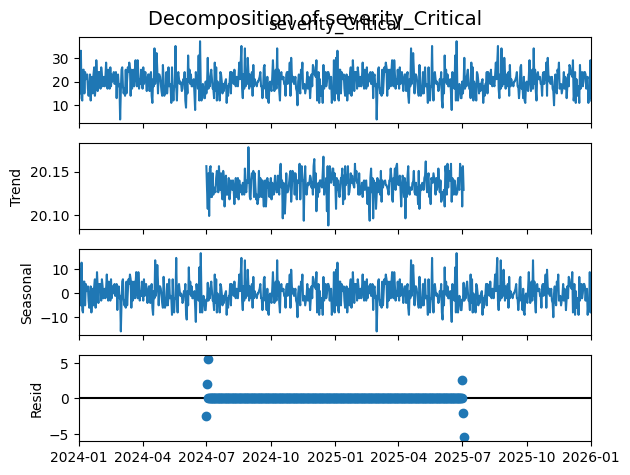


Processing: severity_High


<Figure size 1200x800 with 0 Axes>

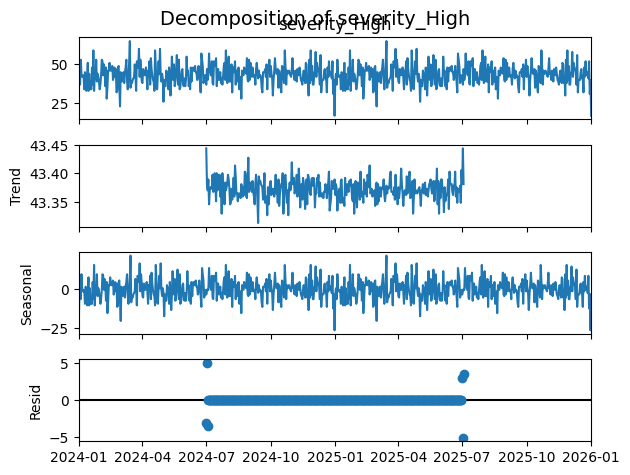


Processing: severity_Low


<Figure size 1200x800 with 0 Axes>

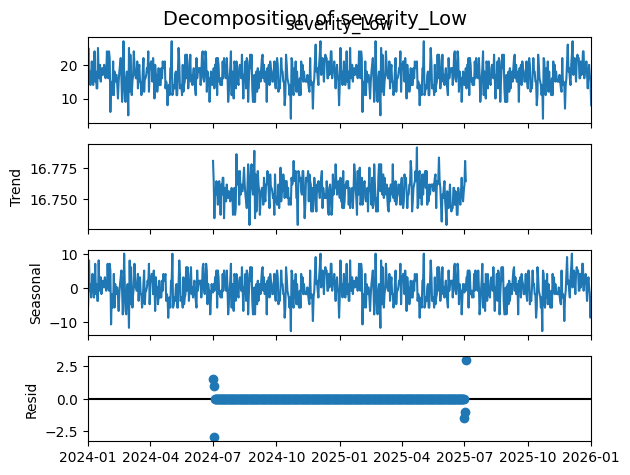


Processing: severity_Medium


<Figure size 1200x800 with 0 Axes>

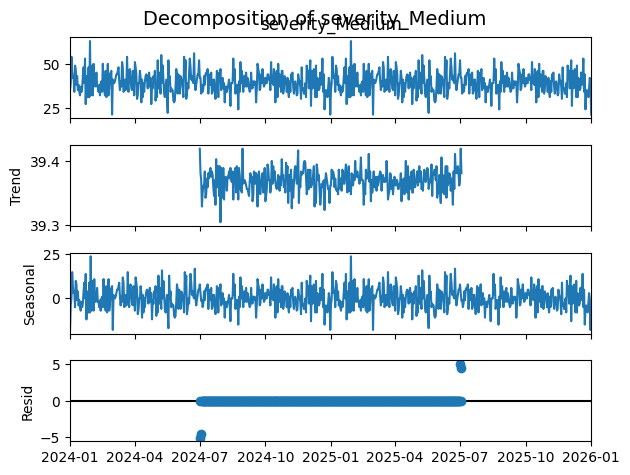


Processing: severity_Very Low


<Figure size 1200x800 with 0 Axes>

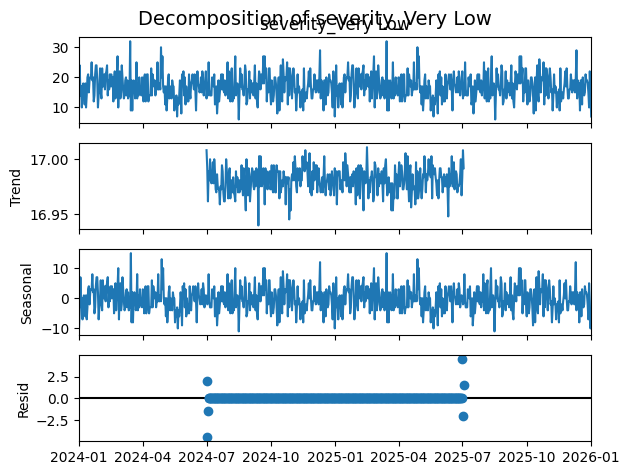

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# -----------------------------
# 2. CREATE TIME SERIES INDEX
# -----------------------------
# Assuming 'day_index' represents the day of the year (1-365/366)
start_date = '2024-01-01' # Choose a starting year for the time series (2024 is a leap year)
df['date'] = pd.to_datetime(start_date) + pd.to_timedelta(df['day_index'] - 1, unit='D')
df = df.sort_values('date')
df.set_index('date', inplace=True)

# -----------------------------
# 3. IDENTIFY SEVERITY COLUMNS
# -----------------------------
severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 4. STORE RESULTS
# -----------------------------
decomposition_results = {}

# -----------------------------
# 5. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:
    print(f"\nProcessing: {col}")

    ts = df[col]

    # Fix: duplicate to create 2 cycles
    ts_extended = pd.concat([ts, ts])

    # Create continuous date index
    ts_extended.index = pd.date_range(start='2024-01-01', periods=len(ts_extended), freq='D')

    # Decompose
    result = seasonal_decompose(ts_extended, model='additive', period=365)

    # Store results
    decomposition_results[col] = result

    # -----------------------------
    # 6. PLOT
    # -----------------------------
    plt.figure(figsize=(12,8))
    result.plot()
    plt.suptitle(f'Decomposition of {col}', fontsize=14)
    plt.show()

In [ ]:
df.head()

,day_index,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low
date,,,,,,
2024-01-01,1,22,40,14,35,13
2024-01-02,2,30,44,25,39,24
2024-01-03,3,15,37,16,54,14
2024-01-04,4,33,53,18,46,17
2024-01-05,5,13,44,14,42,10


In [ ]:
print(df.head())
print(df.index)

            day_index  severity_Critical  severity_High  severity_Low  \
date                                                                    
2024-01-01          1                 22             40            14   
2024-01-02          2                 30             44            25   
2024-01-03          3                 15             37            16   
2024-01-04          4                 33             53            18   
2024-01-05          5                 13             44            14   

            severity_Medium  severity_Very Low  
date                                            
2024-01-01               35                 13  
2024-01-02               39                 24  
2024-01-03               54                 14  
2024-01-04               46                 17  
2024-01-05               42                 10  
DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
   

In [ ]:
# Ensure datetime index (already correct, but safe)
df.index = pd.to_datetime(df.index)

# Set frequency (important for forecasting later)
df = df.asfreq('D')

# Drop unnecessary column
df = df.drop(columns=['day_index'])

# Stationarity Check - ADF Test


===== severity_Critical =====
ADF p-value: 0.0


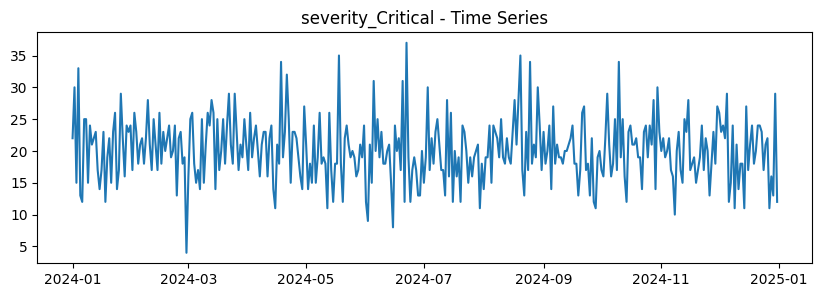

<Figure size 1000x300 with 0 Axes>

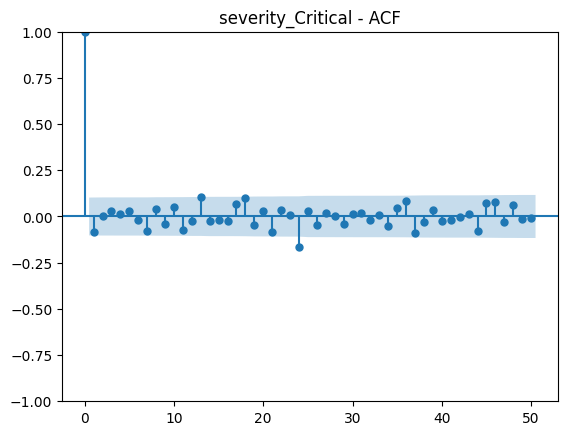

<Figure size 1000x300 with 0 Axes>

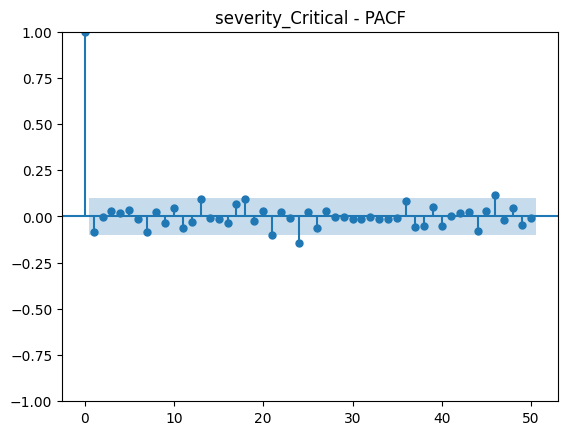


===== severity_High =====
ADF p-value: 0.0


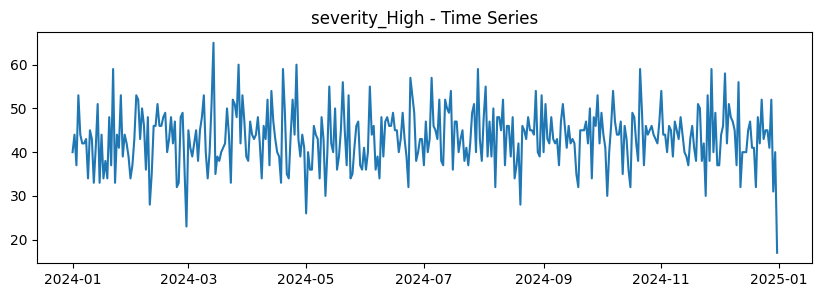

<Figure size 1000x300 with 0 Axes>

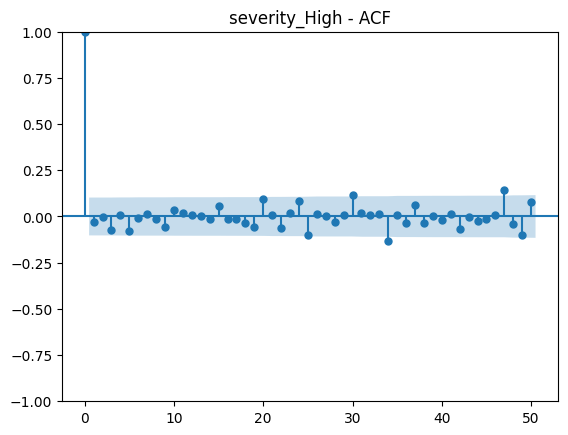

<Figure size 1000x300 with 0 Axes>

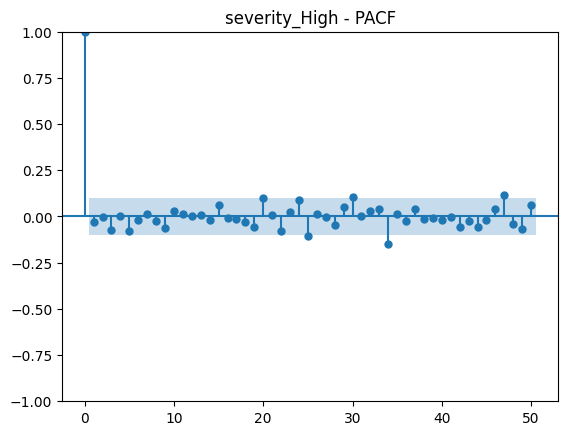


===== severity_Low =====
ADF p-value: 5.4874103570491214e-30


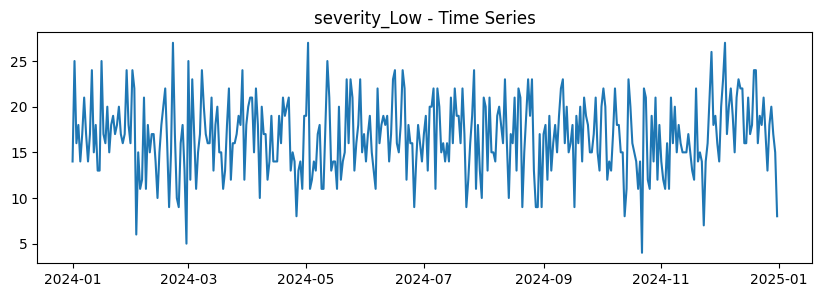

<Figure size 1000x300 with 0 Axes>

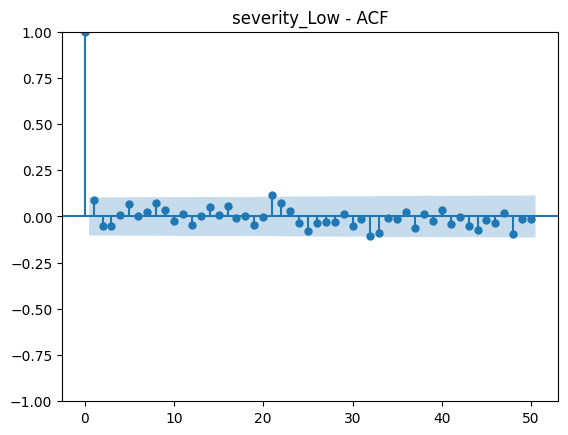

<Figure size 1000x300 with 0 Axes>

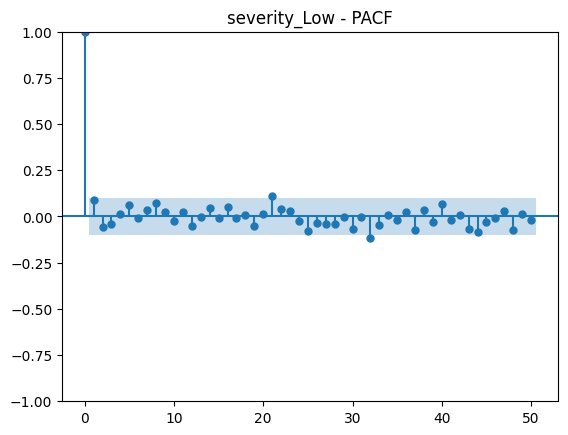


===== severity_Medium =====
ADF p-value: 0.0


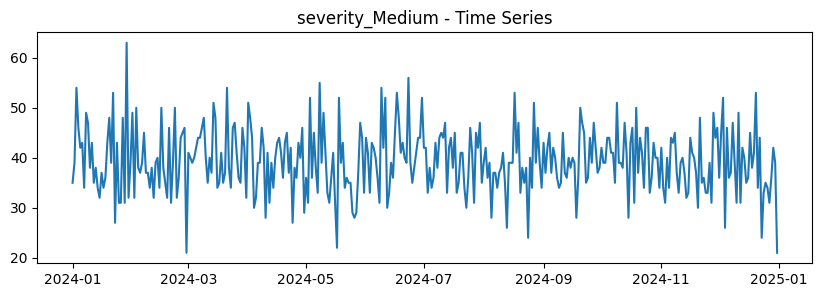

<Figure size 1000x300 with 0 Axes>

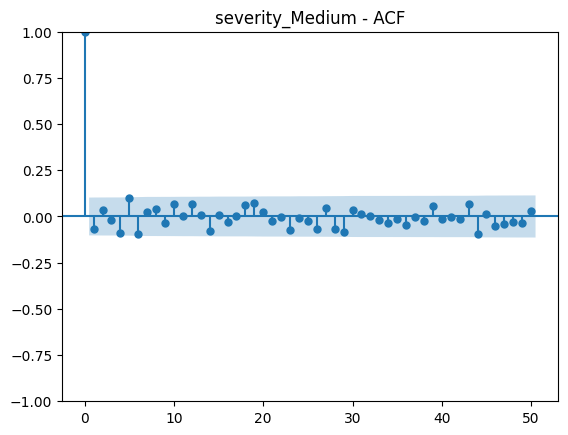

<Figure size 1000x300 with 0 Axes>

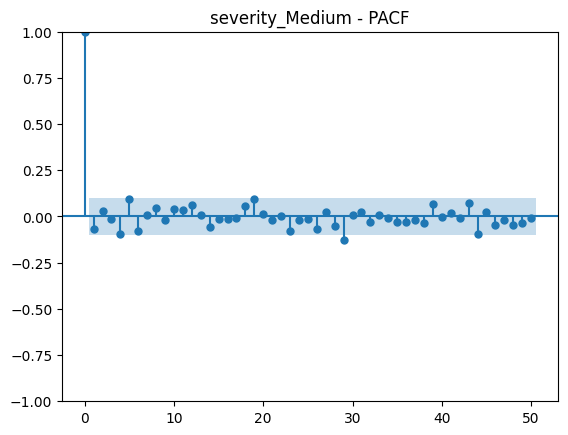


===== severity_Very Low =====
ADF p-value: 0.0


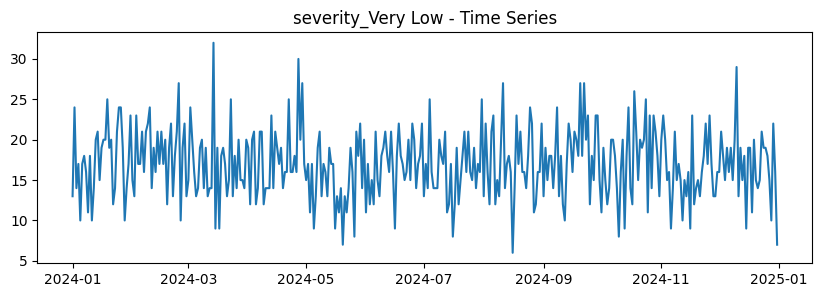

<Figure size 1000x300 with 0 Axes>

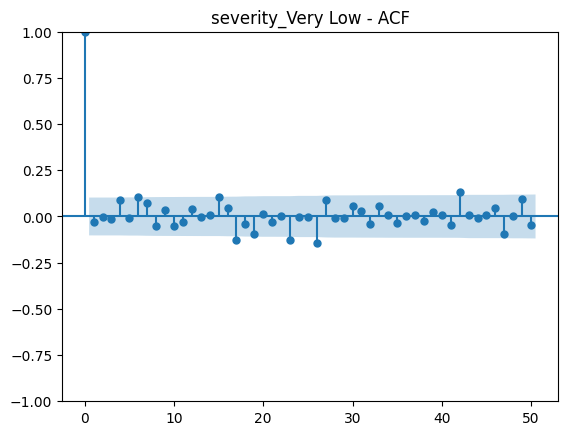

<Figure size 1000x300 with 0 Axes>

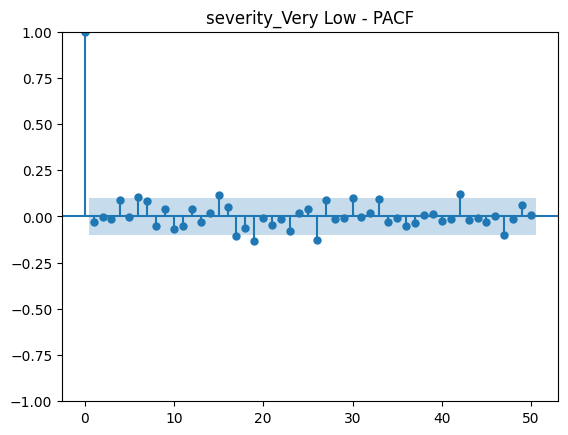

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def full_analysis(series, name):

    print(f"\n===== {name} =====")

    # ADF TEST
    result = adfuller(series.dropna())
    print(f"ADF p-value: {result[1]}")

    # ORIGINAL SERIES
    plt.figure(figsize=(10,3))
    plt.plot(series)
    plt.title(f"{name} - Time Series")
    plt.show()

    # ACF PLOT
    plt.figure(figsize=(10,3))
    plot_acf(series, lags=50)
    plt.title(f"{name} - ACF")
    plt.show()

    # PACF PLOT
    plt.figure(figsize=(10,3))
    plot_pacf(series, lags=50, method='ywm')
    plt.title(f"{name} - PACF")
    plt.show()


# Run for all features
for col in df.columns:
    full_analysis(df[col], col)

In [ ]:
 import pandas as pd

# Load your dataset
df = pd.read_csv('data/processed/month_day_aggregated.csv')

# Sort properly (IMPORTANT before assigning serial numbers)
df = df.sort_values(['month', 'day']).reset_index(drop=True)

# Create serial day index (1 to N)
df['day_index'] = range(1, len(df) + 1)

# Drop month and day columns
df = df.drop(columns=['month', 'day'])

# Reorder columns (optional: keep day_index first)
cols = ['day_index'] + [col for col in df.columns if col != 'day_index']
df = df[cols]

# Save updated dataset
df.to_csv('data/processed/seasonal_index_data.csv', index=False)

# View result
df.head()

,day_index,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low
0,1,22,40,14,35,13
1,2,30,44,25,39,24
2,3,15,37,16,54,14
3,4,33,53,18,46,17
4,5,13,44,14,42,10


In [ ]:
# Save file
df.to_csv('data/processed/seasonal_index_data.csv', index=False)



# ACF & PACF for Model selection


Plotting for: severity_Critical


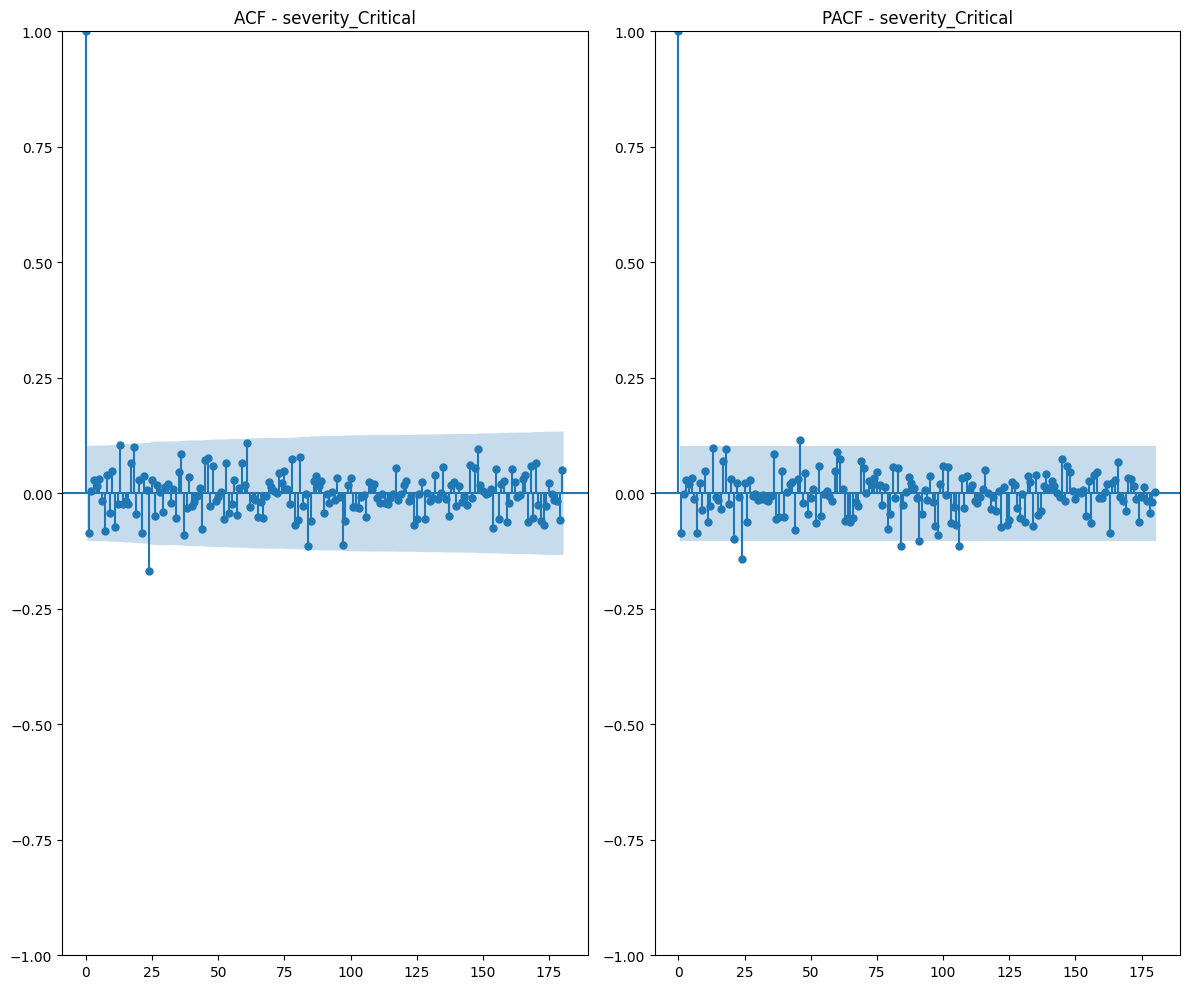


Plotting for: severity_High


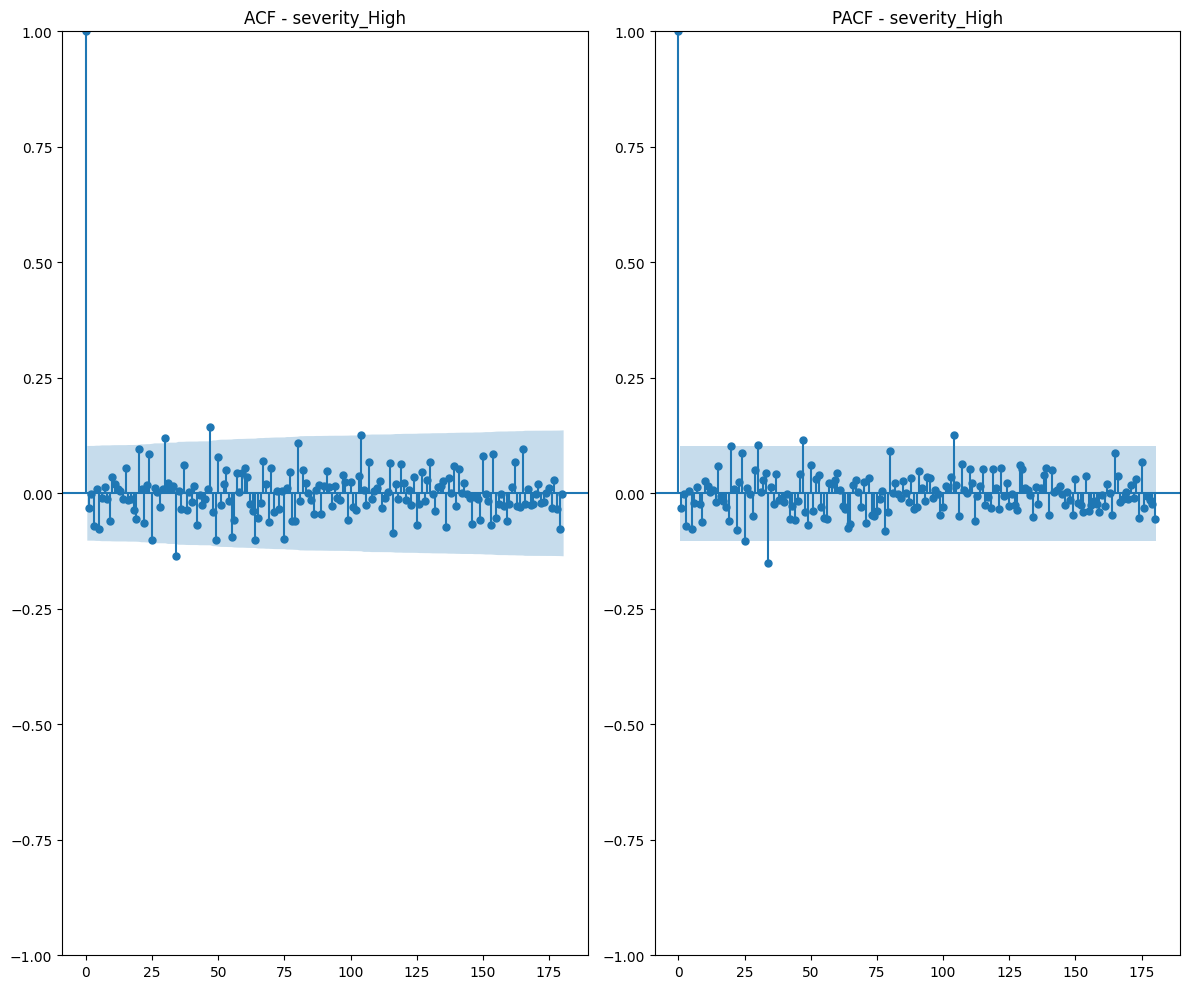


Plotting for: severity_Low


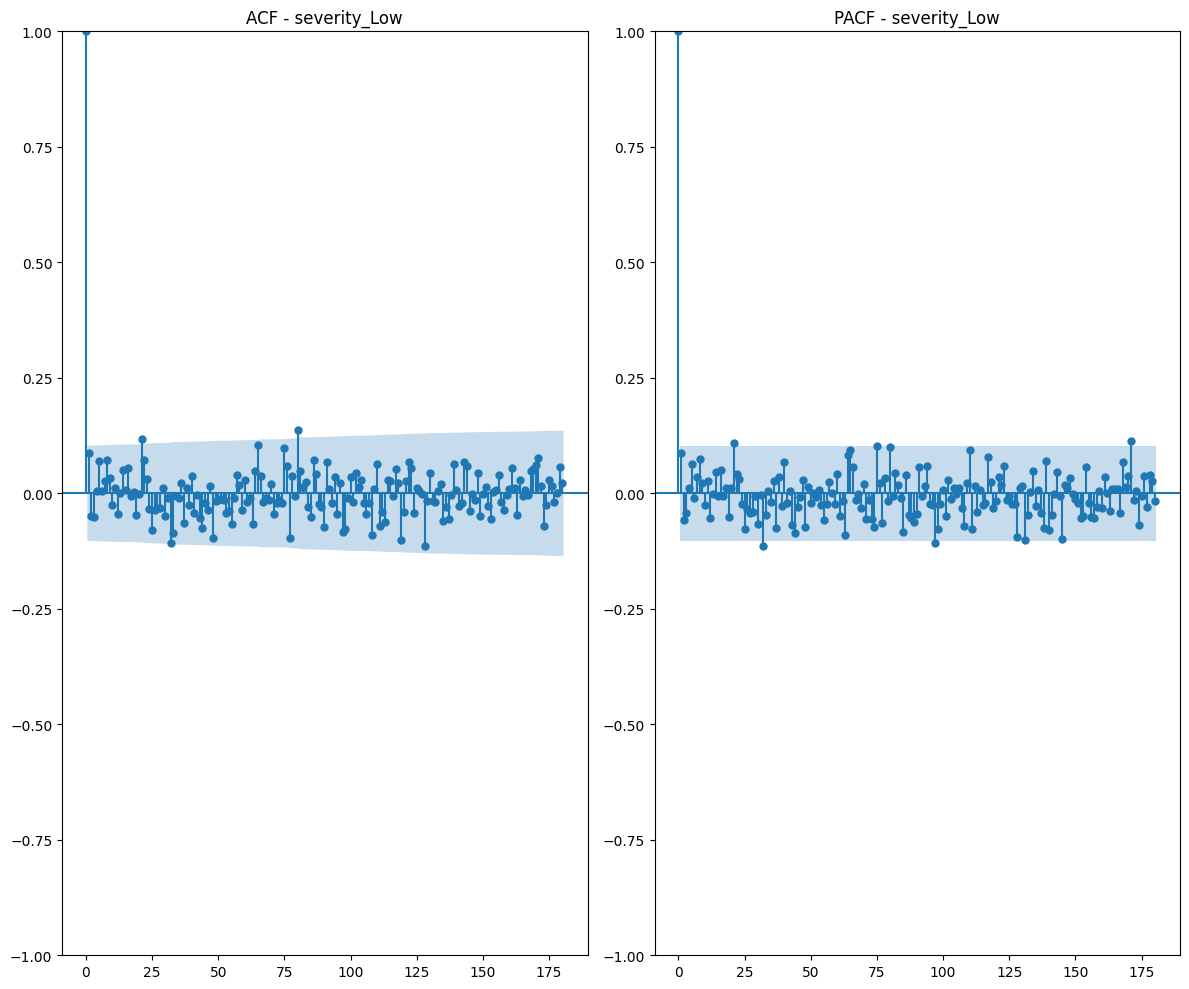


Plotting for: severity_Medium


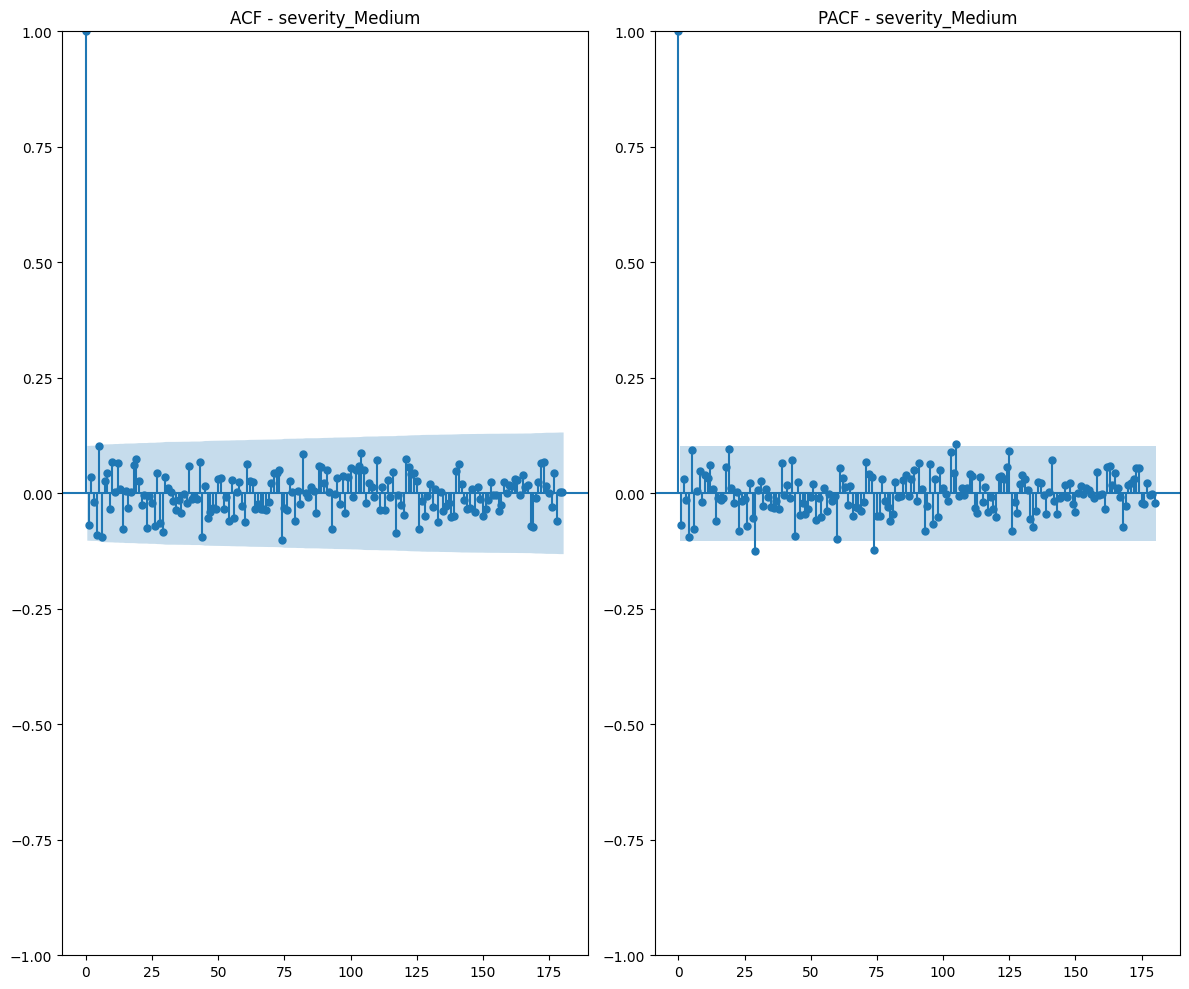


Plotting for: severity_Very Low


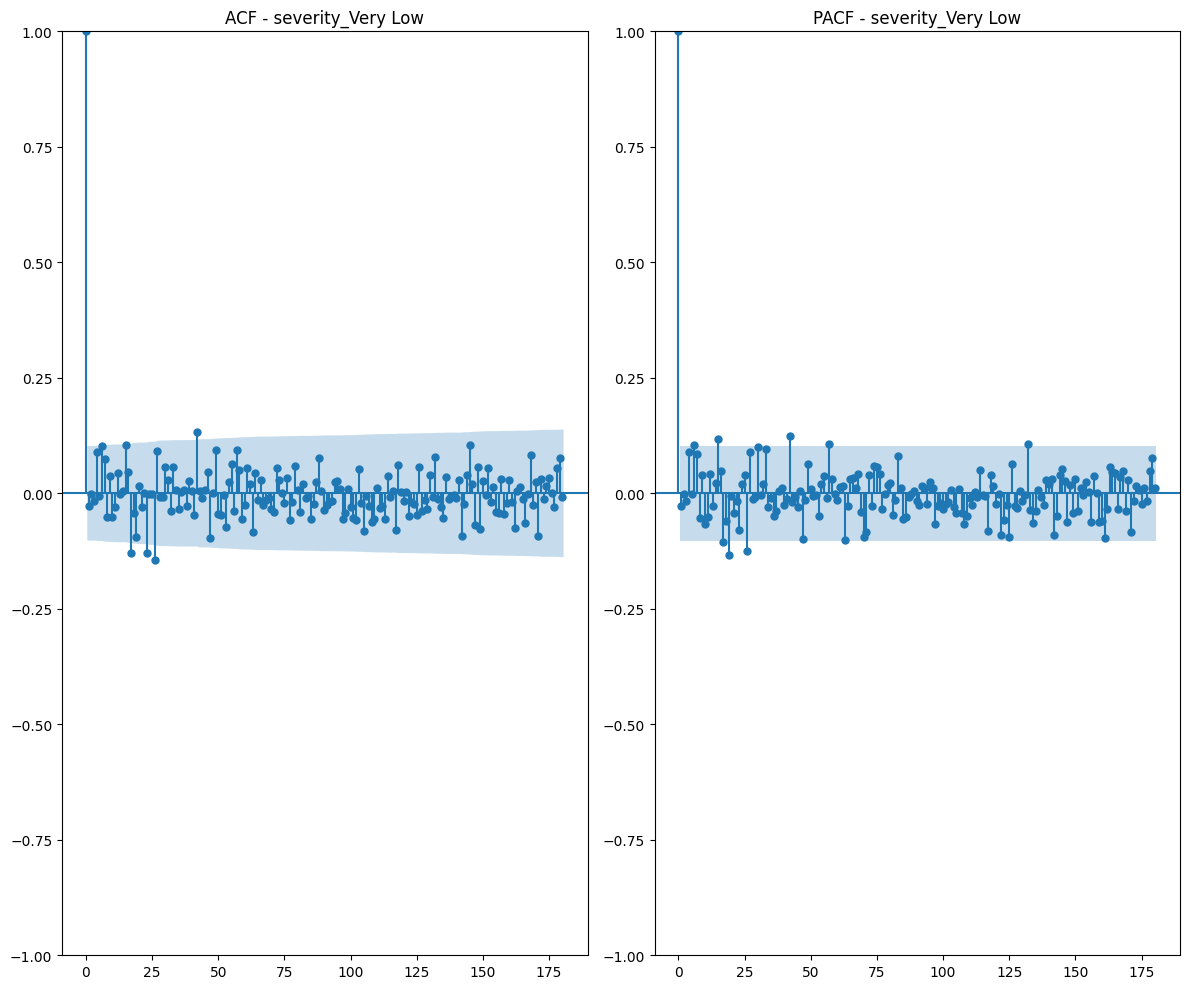

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# -----------------------------
# 2. SET INDEX (important)
# -----------------------------
df.set_index('day_index', inplace=True)

# -----------------------------
# 3. IDENTIFY SEVERITY COLUMNS
# -----------------------------
severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 4. LOOP THROUGH EACH COLUMN
# -----------------------------
for col in severity_cols:
    print(f"\nPlotting for: {col}")

    ts = df[col]

    plt.figure(figsize=(12,10))

    # ACF
    plt.subplot(1, 2, 1)
    plot_acf(ts, lags=180, ax=plt.gca())
    plt.title(f'ACF - {col}')

    # PACF
    plt.subplot(1, 2, 2)
    plot_pacf(ts, lags=180, method='ywm', ax=plt.gca())
    plt.title(f'PACF - {col}')

    plt.tight_layout()
    plt.show()

#MODEL FITTING WITH SELECTION ON LOWEST AIC/BIC values

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

results = []

models = {
    "AR(1)": (1,0,0),
    "MA(1)": (0,0,1),
    "ARMA(1,1)": (1,0,1),
    "AR(2)": (2,0,0)
}

for col in df.columns:
    series = df[col]

    for model_name, order in models.items():
        try:
            model = ARIMA(series, order=order)
            fitted = model.fit()

            results.append({
                "Feature": col,
                "Model": model_name,
                "Order": str(order),
                "AIC": round(fitted.aic, 2),
                "BIC": round(fitted.bic, 2),
                "LogLik": round(fitted.llf, 2)
            })

        except:
            pass

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort properly
results_df = results_df.sort_values(by=["Feature", "AIC"]).reset_index(drop=True)

results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

,Feature,Model,Order,AIC,BIC,LogLik
0,severity_Critical,AR(1),"(1, 0, 0)",2218.63,2230.33,-1106.31
1,severity_Critical,MA(1),"(0, 0, 1)",2218.65,2230.36,-1106.32
2,severity_Critical,AR(2),"(2, 0, 0)",2220.62,2236.23,-1106.31
3,severity_Critical,"ARMA(1,1)","(1, 0, 1)",2220.63,2236.24,-1106.31
4,severity_High,MA(1),"(0, 0, 1)",2422.12,2433.83,-1208.06
5,severity_High,AR(1),"(1, 0, 0)",2422.13,2433.83,-1208.06
6,severity_High,"ARMA(1,1)","(1, 0, 1)",2422.40,2438.01,-1207.20
7,severity_High,AR(2),"(2, 0, 0)",2424.12,2439.74,-1208.06
8,severity_Low,MA(1),"(0, 0, 1)",2071.24,2082.95,-1032.62
9,severity_Low,AR(1),"(1, 0, 0)",2071.56,2083.27,-1032.78


In [ ]:
# Best model per feature (lowest AIC)
best_models = results_df.loc[results_df.groupby('Feature')['AIC'].idxmin()]

best_models = best_models.sort_values(by="Feature").reset_index(drop=True)

print("===== BEST MODEL PER FEATURE =====")
best_models

===== BEST MODEL PER FEATURE =====


,Feature,Model,Order,AIC,BIC,LogLik
0,severity_Critical,AR(1),"(1, 0, 0)",2218.63,2230.33,-1106.31
1,severity_High,MA(1),"(0, 0, 1)",2422.12,2433.83,-1208.06
2,severity_Low,MA(1),"(0, 0, 1)",2071.24,2082.95,-1032.62
3,severity_Medium,AR(1),"(1, 0, 0)",2400.07,2411.78,-1197.04
4,severity_Very Low,MA(1),"(0, 0, 1)",2108.23,2119.94,-1051.12


In [ ]:
pivot_aic = results_df.pivot(index="Feature", columns="Model", values="AIC")
pivot_aic

Model,AR(1),AR(2),"ARMA(1,1)",MA(1)
Feature,,,,
severity_Critical,2218.63,2220.62,2220.63,2218.65
severity_High,2422.13,2424.12,2422.40,2422.12
severity_Low,2071.56,2072.31,2072.93,2071.24
severity_Medium,2400.07,2401.73,2401.85,2400.17
severity_Very Low,2108.24,2110.23,2110.23,2108.23


# Residual Analysis

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

def residual_diagnostics(series, order, name):

    model = ARIMA(series, order=order)
    fitted = model.fit()

    residuals = fitted.resid

    print(f"\n===== {name} | ARIMA{order} =====")

    # Ljung-Box Test
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print("\nLjung-Box Test:")
    print(lb_test)

    # Residual Plot
    plt.figure(figsize=(10,3))
    plt.plot(residuals)
    plt.title("Residuals")
    plt.show()

    # ACF of residuals
    plot_acf(residuals, lags=30)
    plt.title("Residual ACF")
    plt.show()

    # Q-Q Plot
    sm.qqplot(residuals, line='s')
    plt.title("Q-Q Plot")
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



===== severity_Critical | ARIMA(1, 0, 0) =====

Ljung-Box Test:
     lb_stat  lb_pvalue
10  4.782632   0.905217


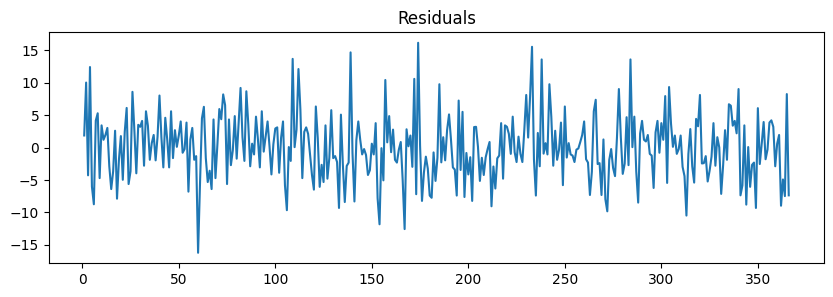

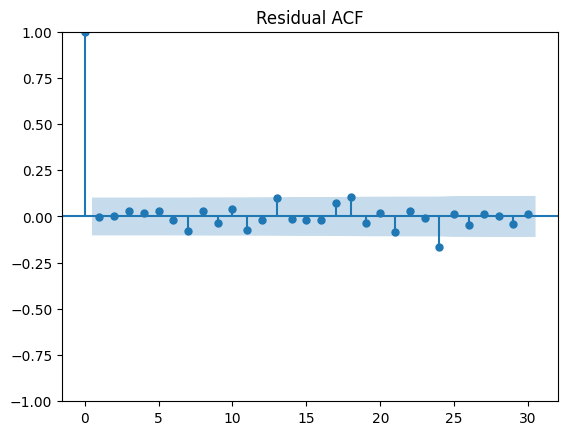

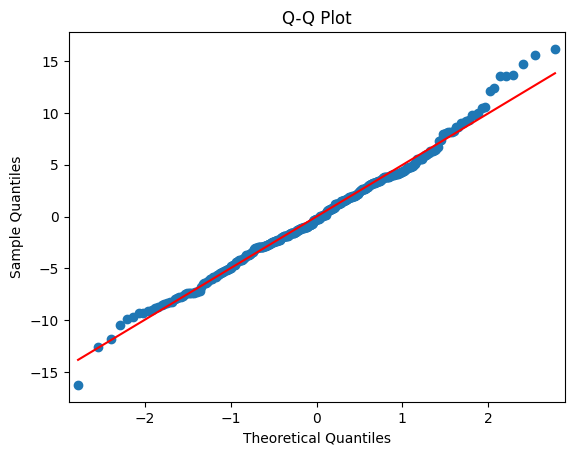

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



===== severity_High | ARIMA(0, 0, 1) =====

Ljung-Box Test:
    lb_stat  lb_pvalue
10  6.04385   0.811566


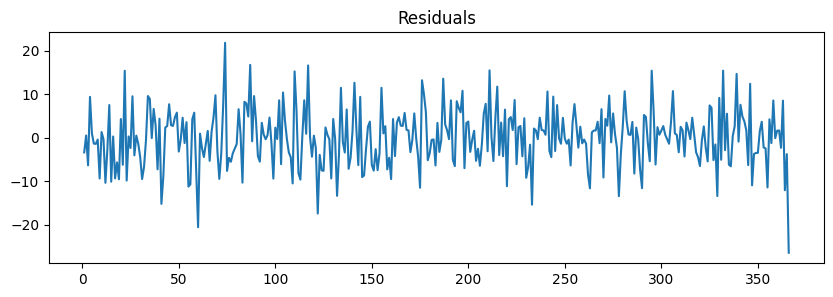

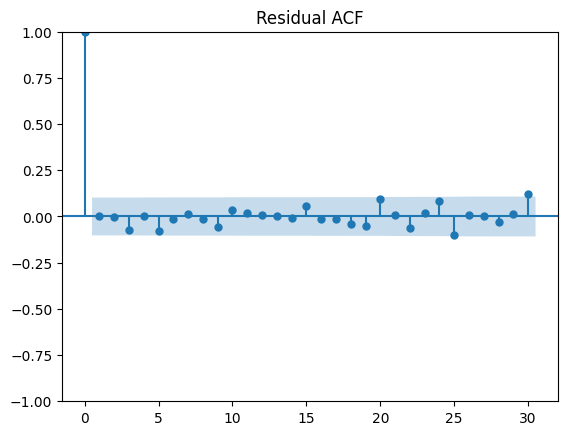

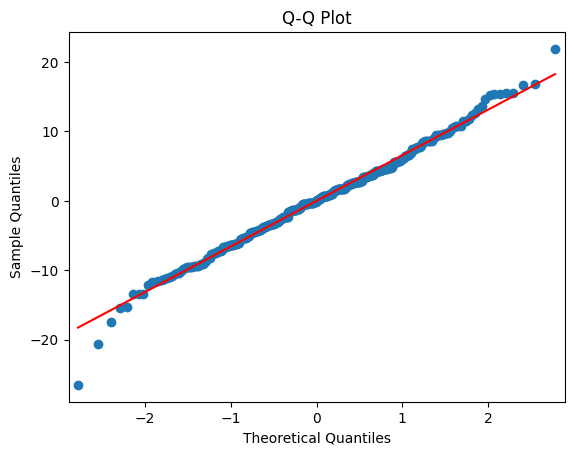

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



===== severity_Low | ARIMA(0, 0, 1) =====

Ljung-Box Test:
     lb_stat  lb_pvalue
10  5.851494   0.827582


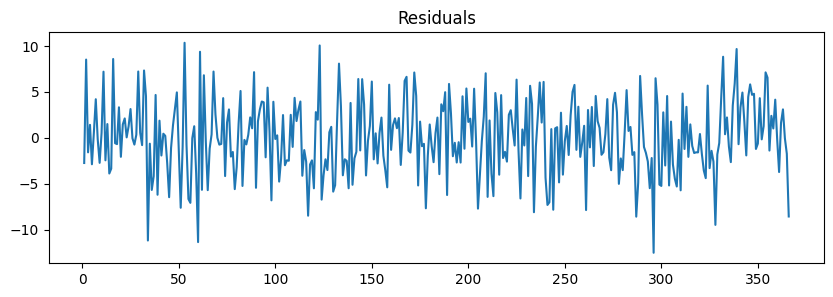

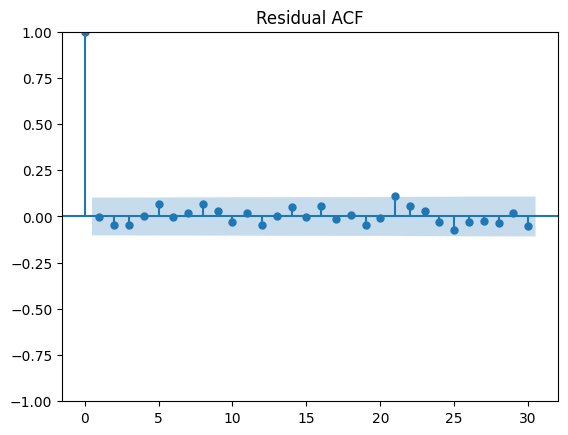

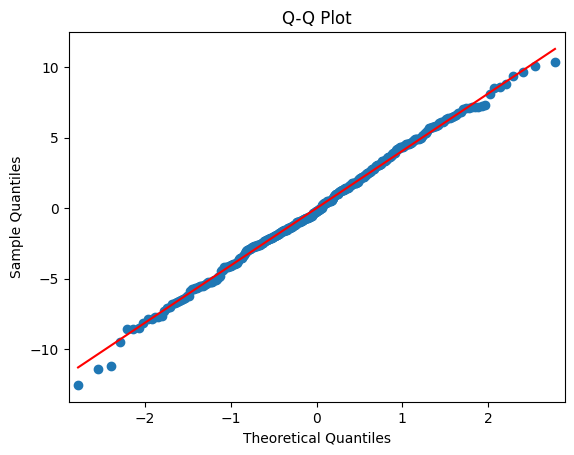

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



===== severity_Medium | ARIMA(1, 0, 0) =====

Ljung-Box Test:
      lb_stat  lb_pvalue
10  11.938937   0.289164


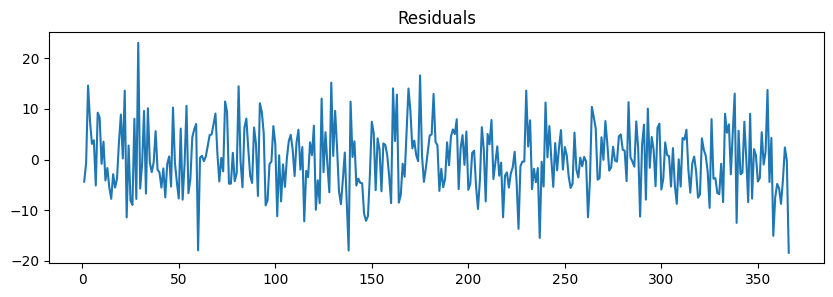

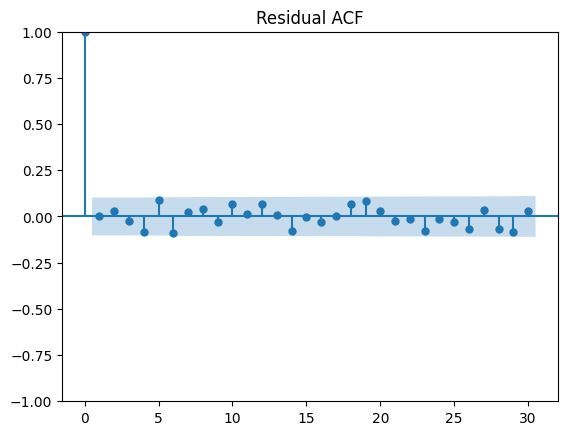

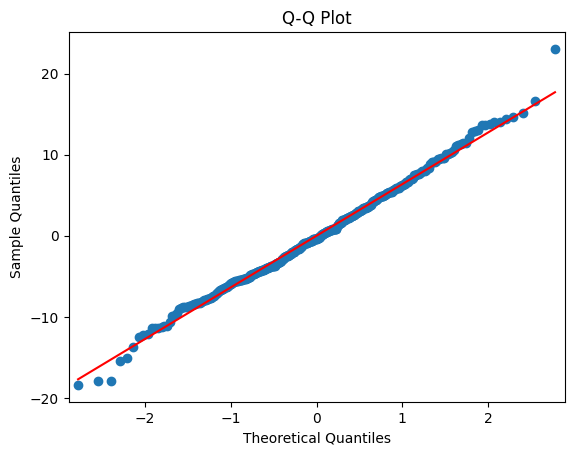

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



===== severity_Very Low | ARIMA(0, 0, 1) =====

Ljung-Box Test:
      lb_stat  lb_pvalue
10  11.620817   0.311235


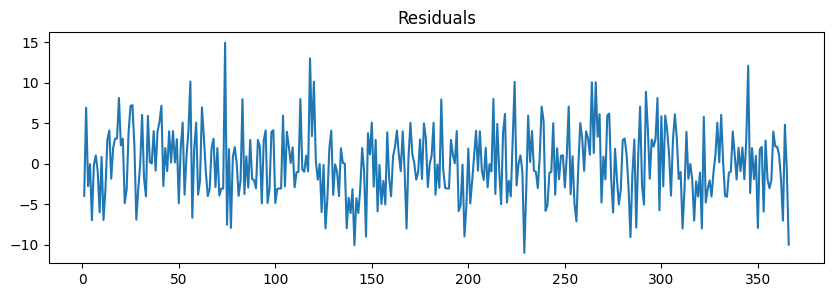

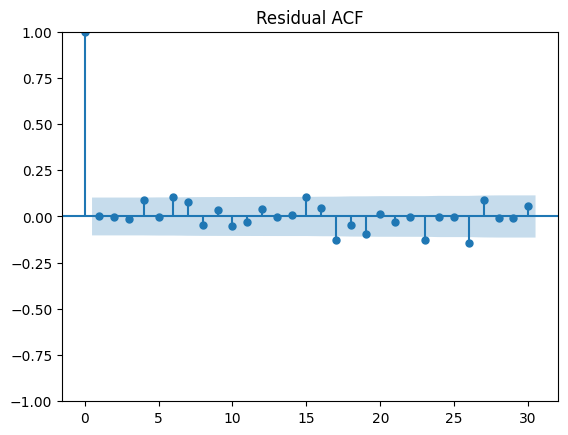

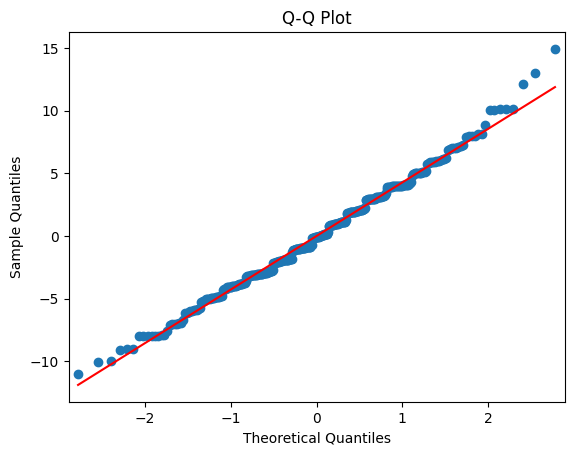

In [ ]:
for i, row in best_models.iterrows():
    feature = row['Feature']
    order = eval(row['Order'])  # converts string "(1,0,1)" â†’ tuple

    residual_diagnostics(df[feature], order, feature)

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Last 30 days as validation
train = df.iloc[:-30]
test = df.iloc[-30:]

In [ ]:
best_orders = {
    "severity_Critical": (1,0,0),
    "severity_High": (0,0,1),
    "severity_Low": (0,0,1),
    "severity_Medium": (1,0,0),
    "severity_Very Low": (0,0,1)
}

# MODEL COMPARISION B/W ARIMA , Holt Winter's

In [ ]:
results = []

for col in df.columns:

    y_train = train[col]
    y_test = test[col]

    # -------- ARIMA --------
    order = best_orders[col]
    arima_model = ARIMA(y_train, order=order).fit()
    arima_forecast = arima_model.forecast(steps=30)

    # -------- Holt-Winters --------
    hw_model = ExponentialSmoothing(
        y_train,
        trend='add',
        seasonal=None   # no seasonality found earlier
    ).fit()

    hw_forecast = hw_model.forecast(30)

    # -------- Metrics --------
    arima_mae = mean_absolute_error(y_test, arima_forecast)
    arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))

    hw_mae = mean_absolute_error(y_test, hw_forecast)
    hw_rmse = np.sqrt(mean_squared_error(y_test, hw_forecast))

    results.append({
        "Feature": col,
        "ARIMA_MAE": round(arima_mae, 2),
        "ARIMA_RMSE": round(arima_rmse, 2),
        "HW_MAE": round(hw_mae, 2),
        "HW_RMSE": round(hw_rmse, 2)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

,Feature,ARIMA_MAE,ARIMA_RMSE,HW_MAE,HW_RMSE
0,severity_Critical,4.51,5.35,4.51,5.30
1,severity_High,5.66,7.92,5.69,8.02
2,severity_Low,3.54,4.46,3.78,4.72
3,severity_Medium,6.23,7.73,6.13,7.65
4,severity_Very Low,3.33,4.28,3.35,4.28


# Forecasting using the Best Model- Holt Winter's


Processing: severity_Critical


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


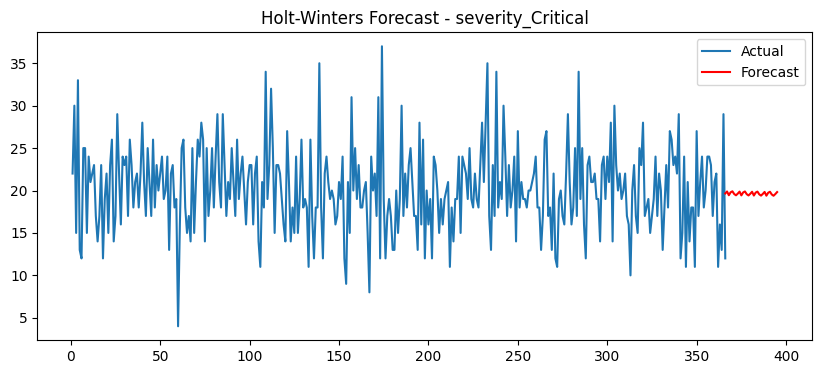


Processing: severity_High


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


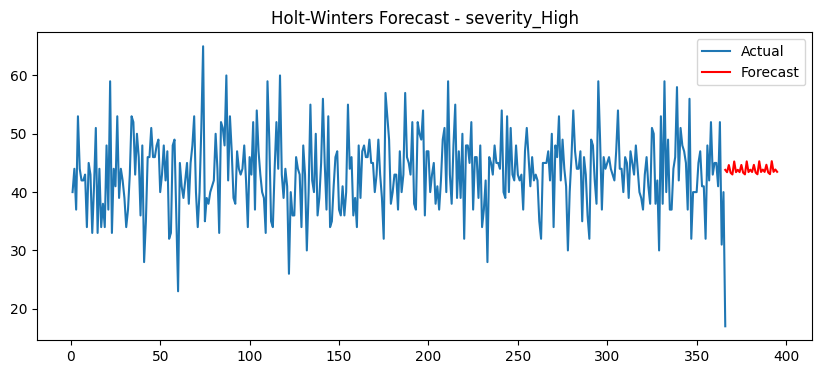

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



Processing: severity_Low


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


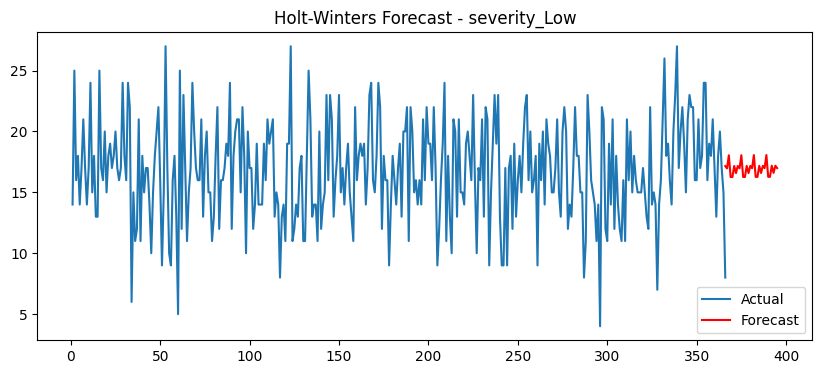


Processing: severity_Medium


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


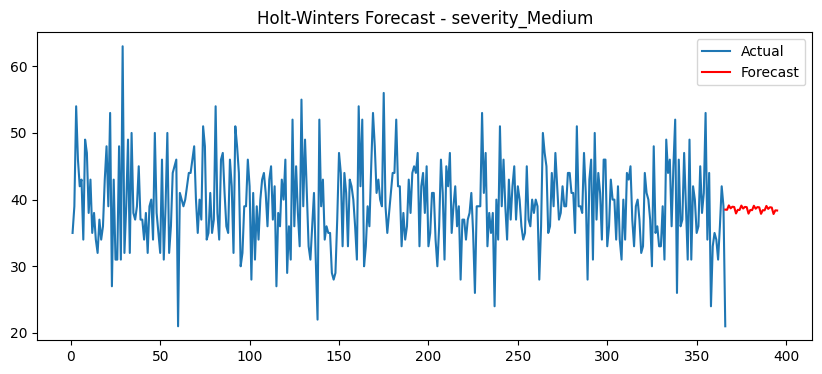


Processing: severity_Very Low


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


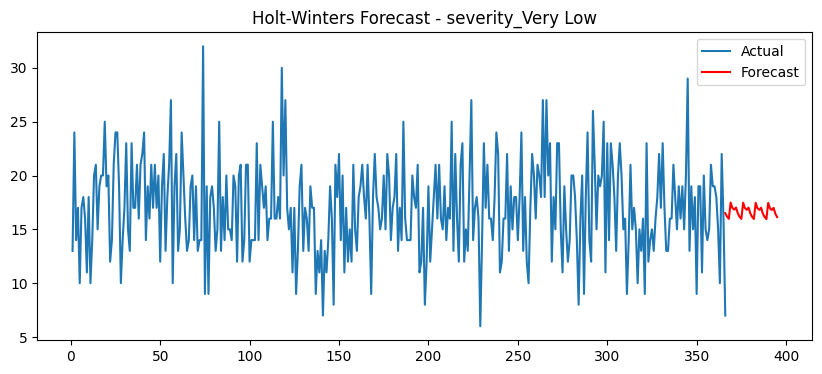

In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')

# Set index
df.set_index('day_index', inplace=True)

# Identify severity columns
severity_cols = [col for col in df.columns if 'severity' in col]

# Store forecasts
forecast_results = {}

# -----------------------------
# 2. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:
    print(f"\nProcessing: {col}")

    ts = df[col]

    # -----------------------------
    # 3. FIT HOLT-WINTERS MODEL
    # -----------------------------
    model = ExponentialSmoothing(
        ts,
        trend='add',
        seasonal='add',
        seasonal_periods=7
    ).fit()

    # -----------------------------
    # 4. FORECAST (next 30 days)
    # -----------------------------
    forecast = model.forecast(30)

    forecast_results[col] = forecast

    # -----------------------------
    # 5. PLOT
    # -----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(ts, label='Actual')
    plt.plot(forecast, label='Forecast', color='red')
    plt.title(f'Holt-Winters Forecast - {col}')
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# =============================
# EVALUATION FUNCTION
# =============================
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')
df.set_index('day_index', inplace=True)

severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 2. TRAIN-TEST SPLIT
# -----------------------------
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# Store results
results = []

# -----------------------------
# 3. LOOP OVER EACH SEVERITY
# -----------------------------
for col in severity_cols:

    print(f"\nProcessing: {col}")

    y_train = train[col]
    y_test = test[col]

    # =============================
    # 1ï¸âƒ£ SEASONALITY MODEL (Naive)
    # =============================
    # Repeat last 7 days pattern
    seasonal_pattern = y_train[-7:].values
    seasonal_forecast = np.tile(seasonal_pattern, int(np.ceil(len(y_test)/7)))[:len(y_test)]

    # =============================
    # 2ï¸âƒ£ HOLT-WINTERS
    # =============================
    hw_model = ExponentialSmoothing(
        y_train,
        trend=None,
        seasonal='add',
        seasonal_periods=7
    ).fit()

    hw_forecast = hw_model.forecast(len(y_test))

    # =============================
    # 3ï¸âƒ£ ARIMA
    # =============================
    # Simple ARIMA (you can tune later)
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    sarima_model = SARIMAX(
        y_train,
        order=(1,1,0),              # same AR part
        seasonal_order=(1,1,1,7)    # (P,D,Q,s) â†’ weekly seasonality
    ).fit(disp=False)

    sarima_forecast = sarima_model.forecast(len(y_test))

    # Compute metrics
    mae_s, rmse_s = evaluate(y_test, seasonal_forecast)
    mae_hw, rmse_hw = evaluate(y_test, hw_forecast)
    mae_ar, rmse_ar = evaluate(y_test, sarima_forecast)

    # Store results
    results.append({
        'Severity': col,
        'Seasonal_MAE': mae_s,
        'Seasonal_RMSE': rmse_s,
        'HW_MAE': mae_hw,
        'HW_RMSE': rmse_hw,
        'ARIMA_MAE': mae_ar,
        'ARIMA_RMSE': rmse_ar
    })

# -----------------------------
# 4. RESULTS TABLE
# -----------------------------
results_df = pd.DataFrame(results)

print("\nFinal Comparison:")
print(results_df)

# Save results
results_df.to_csv('data/processed/model_comparison_results.csv', index=False)


Processing: severity_Critical

Processing: severity_High

Processing: severity_Low

Processing: severity_Medium

Processing: severity_Very Low

Final Comparison:
            Severity  Seasonal_MAE  Seasonal_RMSE    HW_MAE   HW_RMSE  \
0  severity_Critical      5.635135       6.844805  3.911589  4.809983   
1      severity_High      8.121622      10.149557  4.925024  6.805428   
2       severity_Low      4.743243       6.034809  3.458220  4.322957   
3    severity_Medium      7.540541       9.411034  5.305726  6.480717   
4  severity_Very Low      5.756757       7.118685  3.345206  4.177811   

   ARIMA_MAE  ARIMA_RMSE  
0   3.983359    4.878354  
1   6.844844    8.680593  
2   4.098964    5.142710  
3   5.417022    6.832399  
4   7.556684    8.612946  


# Checking Forecasts on Aggregated series

In [ ]:
df["total_incidents"] = df.sum(axis=1)

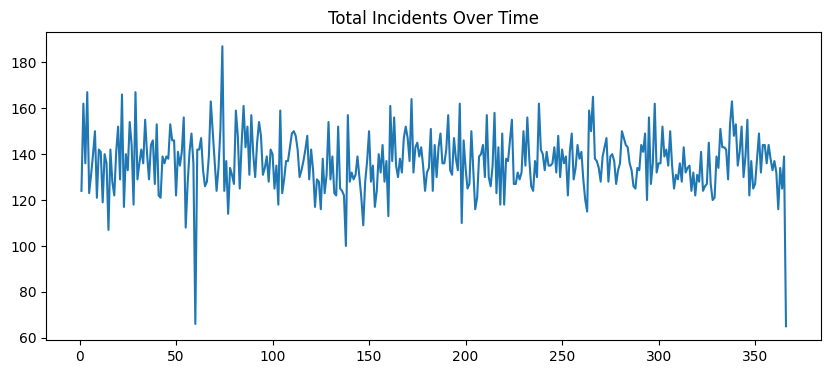

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["total_incidents"])
plt.title("Total Incidents Over Time")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["total_incidents"])
print("p-value:", result[1])

p-value: 1.1292896986680253e-06


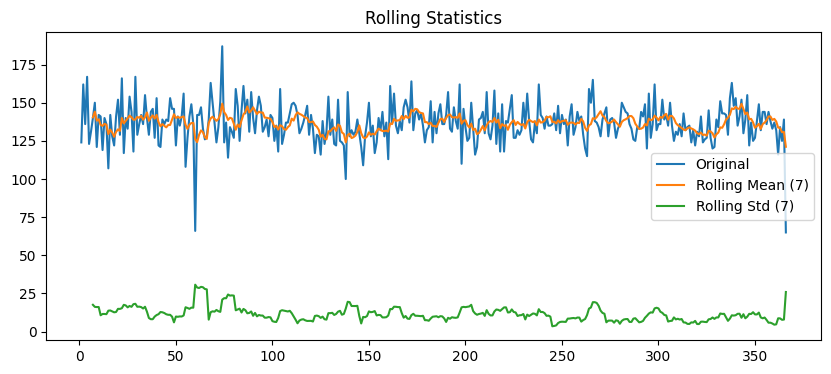

In [ ]:
rolmean = df["total_incidents"].rolling(window=7).mean()
rolstd = df["total_incidents"].rolling(window=7).std()

plt.figure(figsize=(10,4))
plt.plot(df["total_incidents"], label="Original")
plt.plot(rolmean, label="Rolling Mean (7)")
plt.plot(rolstd, label="Rolling Std (7)")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["total_incidents"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: -5.6238113312149975
p-value: 1.1292896986680253e-06
Stationary


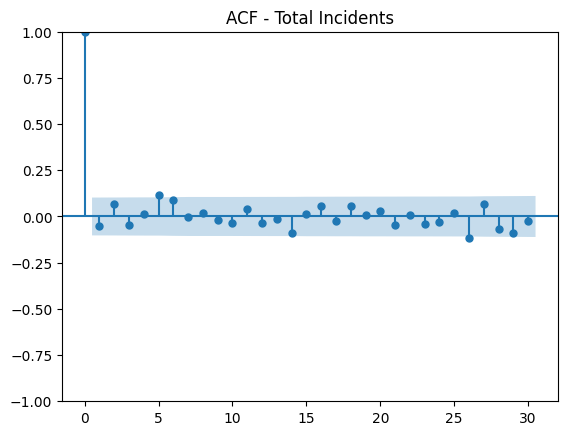

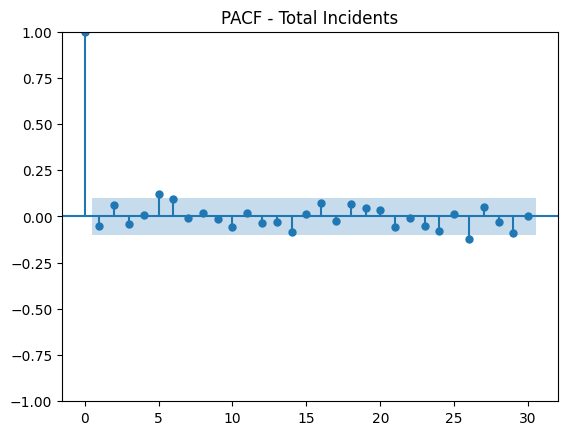

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["total_incidents"], lags=30)
plt.title("ACF - Total Incidents")
plt.show()

plot_pacf(df["total_incidents"], lags=30, method='ywm')
plt.title("PACF - Total Incidents")
plt.show()

In [ ]:
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

series = df["total_incidents"]

p = range(0, 8)   # AR terms
d = [0]           # already stationary
q = range(0, 8)   # MA terms

orders = list(itertools.product(p, d, q))

In [ ]:
results = []

for order in orders:

    try:
        model = ARIMA(series, order=order)
        fitted = model.fit()

        results.append({
            "order": order,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "LogLik": fitted.llf
        })

    except:
        continue

results_df = pd.DataFrame(results)

In [ ]:
results_df = results_df.sort_values(by="AIC").reset_index(drop=True)

print("===== TOP MODELS =====")
results_df.head(10)

===== TOP MODELS =====


,order,AIC,BIC,LogLik
0,"(2, 0, 4)",2911.877802,2943.098868,-1447.938901
1,"(4, 0, 4)",2911.962962,2950.989296,-1445.981481
2,"(1, 0, 5)",2912.347201,2943.568268,-1448.173601
3,"(0, 0, 6)",2912.921812,2944.142879,-1448.460906
4,"(4, 0, 2)",2913.392791,2944.613857,-1448.696395
5,"(5, 0, 6)",2913.412729,2964.146962,-1443.706365
6,"(2, 0, 5)",2913.578045,2948.701745,-1447.789022
7,"(6, 0, 0)",2913.795542,2945.016608,-1448.897771
8,"(0, 0, 5)",2913.815486,2941.133919,-1449.907743
9,"(3, 0, 4)",2913.852325,2948.976025,-1447.926163


In [ ]:
top_models = results_df.head(5)

top_models

,order,AIC,BIC,LogLik
0,"(2, 0, 4)",2911.877802,2943.098868,-1447.938901
1,"(4, 0, 4)",2911.962962,2950.989296,-1445.981481
2,"(1, 0, 5)",2912.347201,2943.568268,-1448.173601
3,"(0, 0, 6)",2912.921812,2944.142879,-1448.460906
4,"(4, 0, 2)",2913.392791,2944.613857,-1448.696395


===== MODEL SUMMARY =====
                               SARIMAX Results                                
Dep. Variable:        total_incidents   No. Observations:                  366
Model:                 ARIMA(2, 0, 4)   Log Likelihood               -1447.939
Date:                Fri, 03 Apr 2026   AIC                           2911.878
Time:                        20:02:37   BIC                           2943.099
Sample:                             0   HQIC                          2924.284
                                - 366                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        136.5435      0.887    153.997      0.000     134.806     138.281
ar.L1          1.3416      0.204      6.590      0.000       0.943       1.741
ar.L2         -0.6053     

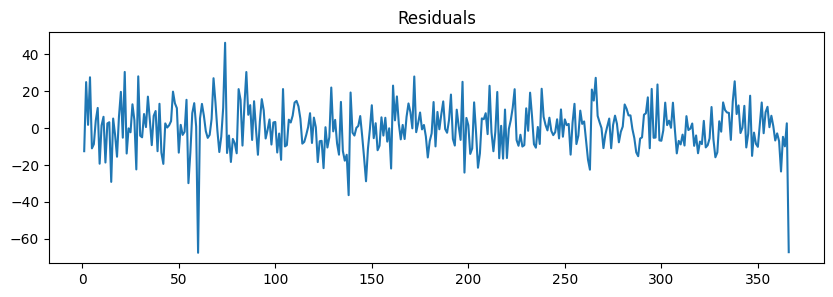

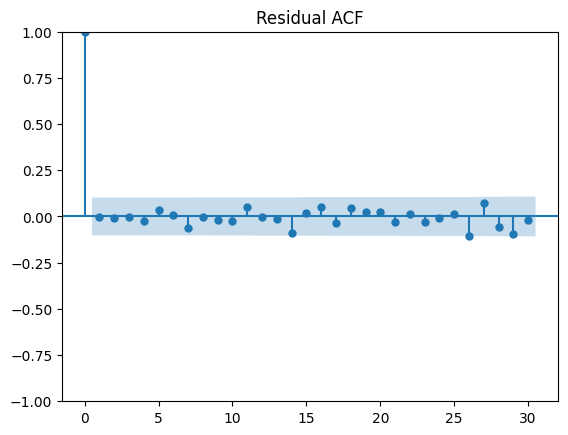


===== Ljung-Box Test =====
     lb_stat  lb_pvalue
10  2.644966   0.988591
20  9.498731   0.976378


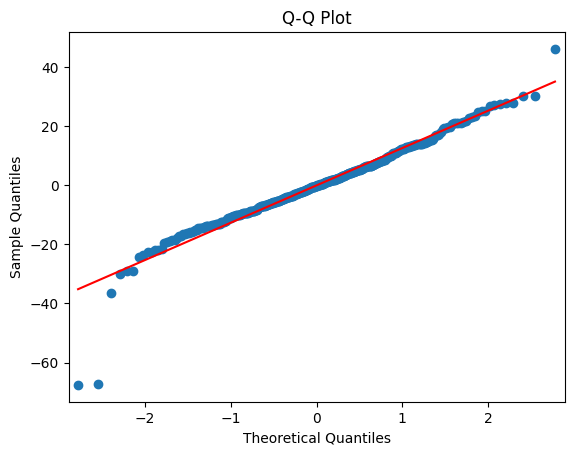

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# -------- BEST MODEL --------
best_order = (2,0,4)
series = df["total_incidents"]

# -------- FIT MODEL --------
model = ARIMA(series, order=best_order)
fitted = model.fit()

print("===== MODEL SUMMARY =====")
print(fitted.summary())

# -------- RESIDUALS --------
residuals = fitted.resid

# -------- RESIDUAL PLOT --------
plt.figure(figsize=(10,3))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

# -------- RESIDUAL ACF --------
plot_acf(residuals, lags=30)
plt.title("Residual ACF")
plt.show()

# -------- LJUNG-BOX TEST --------
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\n===== Ljung-Box Test =====")
print(lb)

# -------- Q-Q PLOT --------
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot")
plt.show()

# Saving Forecasts

In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# -----------------------------
# 1. LOAD FULL DATA
# -----------------------------
df = pd.read_csv('data/processed/seasonal_index_data.csv')
df.set_index('day_index', inplace=True)

severity_cols = [col for col in df.columns if 'severity' in col]

# -----------------------------
# 2. FORECAST HORIZON
# -----------------------------
forecast_horizon = 30   # change to 7 / 14 / 60 as needed

# Store forecasts
final_forecasts = pd.DataFrame()

# -----------------------------
# 3. LOOP THROUGH EACH SEVERITY
# -----------------------------
for col in severity_cols:

    print(f"Forecasting: {col}")

    ts = df[col]

    # Fit Holt-Winters (best config from earlier)
    model = ExponentialSmoothing(
        ts,
        trend=None,
        seasonal='add',
        seasonal_periods=7
    ).fit()

    # Forecast
    forecast = model.forecast(forecast_horizon)

    final_forecasts[col] = forecast.values

# -----------------------------
# 4. ADD DAY INDEX FOR FUTURE
# -----------------------------
last_day = df.index.max()
future_days = range(last_day + 1, last_day + forecast_horizon + 1)

final_forecasts['day_index'] = future_days

# Reorder columns
cols = ['day_index'] + [col for col in final_forecasts.columns if col != 'day_index']
final_forecasts = final_forecasts[cols]

# -----------------------------
# 5. SAVE OUTPUT
# -----------------------------
final_forecasts.to_csv('data/processed/hw_forecast_results.csv', index=False)

print("\nForecast saved at: data/processed/hw_forecast_results.csv")
final_forecasts.head()

Forecasting: severity_Critical
Forecasting: severity_High
Forecasting: severity_Low
Forecasting: severity_Medium
Forecasting: severity_Very Low

Forecast saved at: data/processed/hw_forecast_results.csv


,day_index,severity_Critical,severity_High,severity_Low,severity_Medium,severity_Very Low
0,367,20.115183,43.346154,17.000000,39.211543,16.769231
1,368,20.346168,42.942311,16.807693,39.192307,16.442308
2,369,19.904036,44.173076,17.884617,39.846154,16.250000
3,370,20.250129,42.846156,16.096151,39.403842,17.750000
4,371,20.365434,42.557692,16.096157,39.653845,17.249999


In [1]:
# ============================================================
#  ISP COMPLAINT SEVERITY â€” 30-DAY FORECAST (COLAB READY)
#  Best model per severity band â†’ copper forecast (exact)
#                                â†’ fibre forecast (copper / 4)
#  Output: FINAL_forecast_results_with_5_new_cols format
# ============================================================

# â”€â”€ CELL 1: Install dependencies â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# !pip install statsmodels openpyxl --quiet


# â”€â”€ CELL 2: Imports â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from openpyxl import Workbook
from openpyxl.styles import (
    Font, PatternFill, Alignment, Border, Side
)


# â”€â”€ CELL 3: Config â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# â¬‡  Change this path to wherever your CSV is in Colab
#    e.g. upload via Files panel or mount Google Drive
DATA_PATH   = "data/processed/seasonal_index_data.csv"
OUTPUT_PATH = "data/processed/FINAL_forecast_results_with_5_new_cols.xlsx"
FORECAST_DAYS = 30

FEATURES = [
    "severity_Critical",
    "severity_High",
    "severity_Low",
    "severity_Medium",
    "severity_Very Low",
]

# Best model per band (determined from MAE/RMSE race on 80/20 split)
# Critical  â†’ SES  (Simple Exponential Smoothing â€” stationary, noise-dominated)
# High      â†’ SES  (same reasoning)
# Low       â†’ HW-Mul (Holt-Winters Multiplicative â€” slight weekly seasonality)
# Medium    â†’ ARIMA(2,1,3) (best AIC on full series; captures mild autocorrelation)
# Very Low  â†’ HW-Add (Holt-Winters Additive â€” slight seasonality + minor trend)


# â”€â”€ CELL 4: Load data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = pd.read_csv(DATA_PATH)

# Sanity check
assert all(f in df.columns for f in FEATURES), \
    "One or more severity columns missing from CSV"
print(f"Loaded {len(df)} days of data.")
print(df[FEATURES].tail(3))


# â”€â”€ CELL 5: Fit models & forecast â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
forecasts = {}

for feat in FEATURES:
    series = df[feat].values.astype(float)

    if feat == "severity_Critical":
        # SES â€” optimal smoothing level auto-fitted
        model  = SimpleExpSmoothing(series).fit(optimized=True)
        fc     = model.forecast(FORECAST_DAYS)

    elif feat == "severity_High":
        # SES â€” same
        model  = SimpleExpSmoothing(series).fit(optimized=True)
        fc     = model.forecast(FORECAST_DAYS)

    elif feat == "severity_Low":
        # Holt-Winters Multiplicative (period = 7 days)
        model  = ExponentialSmoothing(
                     series,
                     trend="add",
                     seasonal="mul",
                     seasonal_periods=7
                 ).fit(optimized=True)
        fc     = model.forecast(FORECAST_DAYS)

    elif feat == "severity_Medium":
        # ARIMA(2, 1, 3) â€” best AIC on full series
        model  = ARIMA(series, order=(2, 1, 3)).fit()
        fc     = model.forecast(FORECAST_DAYS)

    elif feat == "severity_Very Low":
        # Holt-Winters Additive (period = 7 days)
        model  = ExponentialSmoothing(
                     series,
                     trend="add",
                     seasonal="add",
                     seasonal_periods=7
                 ).fit(optimized=True)
        fc     = model.forecast(FORECAST_DAYS)

    # Round to nearest integer; clip to minimum of 1
    forecasts[feat] = np.clip(np.round(fc).astype(int), 1, None)
    print(f"{feat:25s}: {forecasts[feat].tolist()}")


# â”€â”€ CELL 6: Build output DataFrame â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Copper columns = exact forecasted values
# Fibre columns  = copper forecast // 4  (integer division, min 1)

out = pd.DataFrame()
out["Forecasted_day_index"] = np.arange(1, FORECAST_DAYS + 1)

col_map = {
    "severity_Critical": ("new_copper_Critical",  "_Critical_Fiber"),
    "severity_High":     ("new_copper_High",       "_High_fibre"),
    "severity_Medium":   ("new_copper_Medium",      "_Medium_fibre"),
    "severity_Low":      ("new_copper_Low",         "_Low_fibre"),
    "severity_Very Low": ("new_copper_Very Low",    "_Very Low_fibre"),
}

copper_order = [
    "new_copper_Critical",
    "new_copper_High",
    "new_copper_Medium",
    "new_copper_Low",
    "new_copper_Very Low",
]
fibre_order = [
    "_Critical_Fiber",
    "_High_fibre",
    "_Medium_fibre",
    "_Low_fibre",
    "_Very Low_fibre",
]

for feat, (copper_col, fibre_col) in col_map.items():
    copper_vals          = forecasts[feat]
    fibre_vals           = np.clip(copper_vals // 4, 1, None)
    out[copper_col]      = copper_vals
    out[fibre_col]       = fibre_vals

# Reorder columns to match reference file exactly
out = out[["Forecasted_day_index"] + copper_order + fibre_order]

print("\nPreview of output:")
print(out.to_string(index=False))


# â”€â”€ CELL 7: Write styled Excel file â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
wb = Workbook()
ws = wb.active
ws.title = "Sheet1"

# â”€â”€ Colour palette â”€â”€
HEADER_COPPER_BG = "1F4E79"   # dark blue
HEADER_FIBRE_BG  = "375623"   # dark green
HEADER_IDX_BG   = "404040"    # dark grey
COPPER_BG        = "D6E4F0"   # light blue
FIBRE_BG         = "E2EFDA"   # light green
IDX_BG           = "F2F2F2"   # light grey
WHITE            = "FFFFFF"
HEADER_FONT      = Font(name="Arial", bold=True, color=WHITE, size=10)
DATA_FONT        = Font(name="Arial", size=10)
CENTER           = Alignment(horizontal="center", vertical="center", wrap_text=True)

thin = Side(style="thin", color="AAAAAA")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

def fill(hex_color):
    return PatternFill("solid", fgColor=hex_color)

# â”€â”€ Write header row â”€â”€
headers = list(out.columns)
for c_idx, col_name in enumerate(headers, start=1):
    cell = ws.cell(row=1, column=c_idx, value=col_name)
    cell.alignment = CENTER
    cell.font      = HEADER_FONT
    cell.border    = border
    if col_name == "Forecasted_day_index":
        cell.fill = fill(HEADER_IDX_BG)
    elif col_name.startswith("new_copper"):
        cell.fill = fill(HEADER_COPPER_BG)
    else:
        cell.fill = fill(HEADER_FIBRE_BG)

# â”€â”€ Write data rows â”€â”€
for r_idx, row in out.iterrows():
    excel_row = r_idx + 2   # row 1 = header
    for c_idx, (col_name, val) in enumerate(row.items(), start=1):
        cell = ws.cell(row=excel_row, column=c_idx, value=int(val))
        cell.font      = DATA_FONT
        cell.alignment = CENTER
        cell.border    = border
        if col_name == "Forecasted_day_index":
            cell.fill = fill(IDX_BG)
        elif col_name.startswith("new_copper"):
            cell.fill = fill(COPPER_BG)
        else:
            cell.fill = fill(FIBRE_BG)

# â”€â”€ Column widths â”€â”€
ws.column_dimensions["A"].width = 22     # Forecasted_day_index
for col_letter in ["B","C","D","E","F"]:
    ws.column_dimensions[col_letter].width = 20   # copper cols
for col_letter in ["G","H","I","J","K"]:
    ws.column_dimensions[col_letter].width = 18   # fibre cols

# â”€â”€ Freeze header row â”€â”€
ws.freeze_panes = "A2"

# â”€â”€ Save â”€â”€
wb.save(OUTPUT_PATH)
print(f"\nâœ…  Saved â†’ {OUTPUT_PATH}")
print(f"   Shape : {out.shape[0]} rows Ã— {out.shape[1]} columns")
print(f"   Cols  : {list(out.columns)}")

Loaded 366 days of data.
     severity_Critical  severity_High  severity_Low  severity_Medium  \
363                 13             31            17               42   
364                 29             40            15               39   
365                 12             17             8               21   

     severity_Very Low  
363                 22  
364                 16  
365                  7  
severity_Critical        : [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
severity_High            : [43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43, 43]
severity_Low             : [17, 16, 17, 16, 16, 17, 16, 17, 16, 17, 16, 16, 17, 16, 17, 16, 17, 16, 16, 17, 16, 17, 16, 17, 16, 16, 17, 16, 17, 16]
severity_Medium          : [41, 38, 39, 40, 38, 41, 39, 39, 40, 38, 40, 39, 40, 40, 39, 40, 39, 40, 40, 39, 40, 39, 40, 39, 39, 40, 39, 39, 39